In [2]:
# Import necessary libraries
import numpy as np 
import matplotlib.pyplot as plt
import scipy.stats as stats
import scipy as sp
from scipy import integrate
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LogNorm
import latex

# Set the plotting style to use LaTeX for rendering text
plt.style.use('tex')

Bad value in file WindowsPath('c:/Users/Renzovm/AppData/Local/Programs/Python/Python313/Lib/site-packages/matplotlib/mpl-data/stylelib/tex.mplstyle'), line 13 ('ytick.labelsize:       smalls'): Key ytick.labelsize: smalls is not a valid font size. Valid font sizes are xx-small, x-small, small, medium, large, x-large, xx-large, smaller, larger.


In [3]:
# Function to set figure dimensions to avoid scaling in LaTeX
def set_size(width, fraction=1, subplots=(1, 1)):
    """Set figure dimensions to avoid scaling in LaTeX.

    Parameters
    ----------
    width: float or string
            Document width in points, or string of predined document type
    fraction: float, optional
            Fraction of the width which you wish the figure to occupy
    subplots: array-like, optional
            The number of rows and columns of subplots.
    Returns
    -------
    fig_dim: tuple
            Dimensions of figure in inches
    """
    if width == 'thesis':
        width_pt = 426.79135
    elif width == 'beamer':
        width_pt = 307.28987
    else:
        width_pt = width

    # Width of figure (in pts)
    fig_width_pt = width_pt * fraction
    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Golden ratio to set aesthetic figure height
    # https://disq.us/p/2940ij3
    golden_ratio = (5**.5 - 1) / 2

    # Figure width in inches
    fig_width_in = fig_width_pt * inches_per_pt
    # Figure height in inches
    fig_height_in = fig_width_in * (subplots[0] / subplots[1])

    return (fig_width_in, fig_height_in)

## Potential Landscape

In [4]:
#Hybrid Inflation Potential 
def V(sigma, phi, M, lamb, m, g):
    """
    Potential for the hybrid inflation model.
    Parameters:
    sigma: Higgs field, scalar
    phi: inflaton field, scalar
    M: scalar
    lamb: scalar
    m: scalar
    """
    pot = (1/(4*lamb))*((M**2-lamb*sigma**2)**2) + ((m**2)/2)*phi**2 + (g**2/2)*(sigma**2)*(phi**2)
    return pot


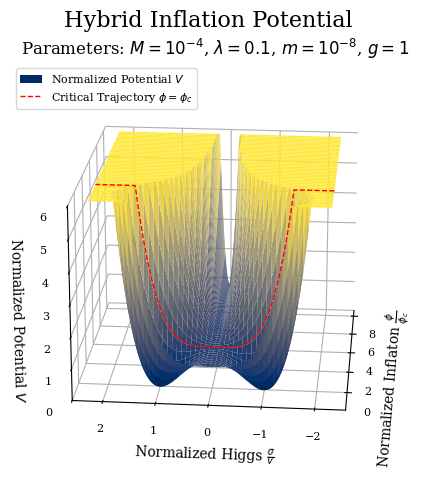

In [10]:
# Hybrid inflation parameters
M = 10**(6)*10**(-10)
lamb = 0.1
m = 10**(2)*10**(-10)
g = 1.0

# critical phi
phi_c = M / g

# Use normalized plotting variables so transition and wells are easy to see
phi_n = np.linspace(-1, 8.0, 5000)
phi = phi_n * phi_c
sigma_n = np.linspace(-2.25, 2.25, 5000)
sigma = sigma_n * (M/np.sqrt(lamb))

# Create meshgrids
Phi_n, Sigma_n = np.meshgrid(phi_n, sigma_n)
Phi, Sigma = np.meshgrid(phi, sigma)

# Compute and normalize potential for visualization
V_values = V(Sigma, Phi, M, lamb, m, g)
V_values = V_values / V(0,0, M, lamb, m, g)  # normalized so numbers are O(1)
for i in range(len(V_values)):
    for j in range(len(V_values[0])):
        if V_values[i][j] > 6:
            V_values[i][j] = 6
# Plot the surface (normalized axes)
fig = plt.figure(figsize=set_size('thesis', fraction=0.9))
ax = fig.add_subplot(111, projection='3d', computed_zorder=False)
surf = ax.plot_surface(Phi_n, Sigma_n, V_values, antialiased=True, 
                       cmap='cividis', edgecolor='none', label=r'Normalized Potential $V$')
V_critic_traj = V(sigma, phi_c, M, lamb, m, g) / V(0,0, M, lamb, m, g)

for i in range(len(V_critic_traj)):
    if V_critic_traj[i] > 6:
        V_critic_traj[i] = 6

ax.plot3D(1, sigma_n, V_critic_traj, color='red', linestyle='--', linewidth=1, label=r'Critical Trajectory $\phi=\phi_c$')
ax.xaxis.pane.set_alpha(0)
ax.yaxis.pane.set_alpha(0)
ax.zaxis.pane.set_alpha(0)
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.set_xlabel(r'Normalized Inflaton $\frac{\phi}{\phi_c}$', fontsize=10)
ax.set_ylabel(r'Normalized Higgs $\frac{\sigma}{v}$', rotation=90, fontsize=10)
ax.set_zlabel(r'Normalized Potential $V$', fontsize=10)
ax.tick_params(labelsize=8)
ax.set_zlim(0, 6)
ax.legend(loc='upper left', fontsize=8)
ax.set_title(rf"Parameters: $M=10^{{-4}}$, $\lambda={lamb:.2g}$, $m=10^{{-8}}$, $g={g:.2g}$", fontsize=12)
fig.suptitle('Hybrid Inflation Potential', fontsize=16)
ax.view_init(elev=20, azim=185)
fig.savefig('Hybrid_Inflation_Potential.pdf', format = 'pdf', bbox_inches='tight')
plt.show()

In [5]:
print(rf"{M**2} >> {(lamb*(m**2))/(g**2)}")
print(rf"{M**3} << {lamb*m}")
print(rf"{M**3} << {np.sqrt(lamb)*g*m}")

1e-08 >> 1.0000000000000002e-17
1.0000000000000002e-12 << 1e-09
1.0000000000000002e-12 << 3.1622776601683795e-09


In [6]:
# Hybrid inflation parameters
M = 10**(6)*10**(-10)
lamb = 0.1
m = 10**(2)*10**(-10)
g = 1.0

# critical phi
phi_c = M / g

# Use normalized plotting variables so transition and wells are easy to see
phi_n = np.linspace(-1, 8.0, 5000)
phi = phi_n * phi_c
phi = np.linspace(-1, 8.0, 5000) * 10**(-4)
sigma_n = np.linspace(-2.25, 2.25, 5000)
sigma = sigma_n * (M/np.sqrt(lamb))
sigma = np.linspace(-2.25, 2.25, 5000)*5*10**(-4)

# Create meshgrids
Phi_n, Sigma_n = np.meshgrid(phi_n, sigma_n)
Phi, Sigma = np.meshgrid(phi, sigma)

# Compute and normalize potential for visualization
V_values = V(Sigma, Phi, M, lamb, m, g)
#V_values = V_values / V(0,0, M, lamb, m, g)  # normalized so numbers are O(1)
for i in range(len(V_values)):
    for j in range(len(V_values[0])):
        if V_values[i][j] > 6*10**(-16):
            V_values[i][j] = 6*10**(-16)
# Plot the surface (normalized axes)
fig = pyplot.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(Phi, Sigma, V_values, linewidth=0, antialiased=True, cmap='cividis')
ax.set_xlabel(r'Normalized inflaton $\frac{\phi}{\phi_c}$')
ax.set_ylabel(r'Normalized Higgs $\frac{\sigma}{v}$', rotation=90)
ax.set_zlabel(r'Normalized potential $V$')
ax.set_title(rf"Parameters: $M={M:.2g}$, $\lambda={lamb:.2g}$, $m={m:.2g}$, $g={g:.2g}$", fontsize=12)
fig.suptitle('Hybrid Inflation Potential', fontsize=16)
ax.view_init(elev=25, azim=190)
pyplot.show()

NameError: name 'pyplot' is not defined

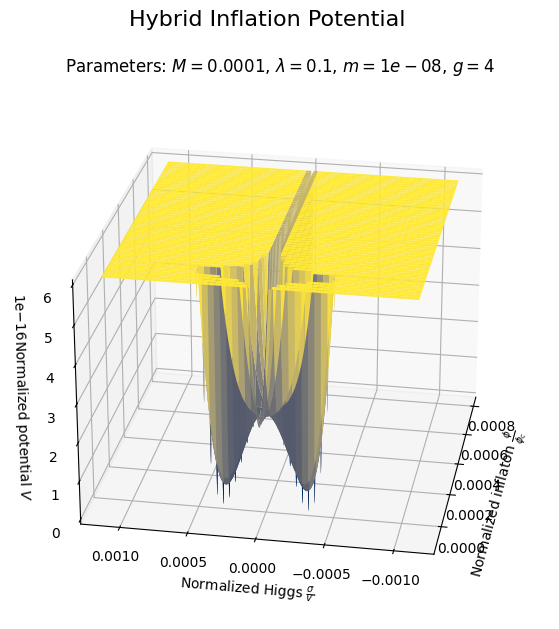

In [ ]:
# Hybrid inflation parameters
M = 10**(6)*10**(-10)
lamb = 0.1
m = 10**(2)*10**(-10)
g = 4.0

# critical phi
phi_c = M / g

# Use normalized plotting variables so transition and wells are easy to see
phi_n = np.linspace(-1, 4.0, 5000)
phi = phi_n * phi_c
phi = np.linspace(-1, 8.0, 5000) * 10**(-4)
sigma_n = np.linspace(-2.25, 2.25, 5000)
sigma = sigma_n * (M/np.sqrt(lamb))
sigma = np.linspace(-2.25, 2.25, 5000)*5*10**(-4)

# Create meshgrids
Phi_n, Sigma_n = np.meshgrid(phi_n, sigma_n)
Phi, Sigma = np.meshgrid(phi, sigma)

# Compute and normalize potential for visualization
V_values = V(Sigma, Phi, M, lamb, m, g)
#V_values = V_values / V(0,0, M, lamb, m, g)  # normalized so numbers are O(1)
for i in range(len(V_values)):
    for j in range(len(V_values[0])):
        if V_values[i][j] > 6*10**(-16):
            V_values[i][j] = 6*10**(-16)
# Plot the surface (normalized axes)
fig = pyplot.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(Phi, Sigma, V_values, linewidth=0, antialiased=True, cmap='cividis')
ax.set_xlabel(r'Normalized inflaton $\frac{\phi}{\phi_c}$')
ax.set_ylabel(r'Normalized Higgs $\frac{\sigma}{v}$', rotation=90)
ax.set_zlabel(r'Normalized potential $V$')
ax.set_title(rf"Parameters: $M={M:.2g}$, $\lambda={lamb:.2g}$, $m={m:.2g}$, $g={g:.2g}$", fontsize=12)
fig.suptitle('Hybrid Inflation Potential', fontsize=16)
ax.view_init(elev=25, azim=190)
pyplot.show()

## Solving EOM

In [ ]:
def eof(params, phi_in_n = 1, sigma_in = 10**(-7), tdiffbig = 100 ,tdiffsmall = 0.1 ,M_p = 1, tdiffdetail = 0.1):
    """
    Function to compute the end of inflation for the hybrid inflation model.
    Parameters:
    params: list of parameters [M, lamb, m, g]
    phi_in_n: initial value of the inflaton field (normalized)
    tdiff: time step for numerical integration
    M_p: Planck mass (set to 1 for natural units)
    epsilon_detail: detail level for epsilon-dependent time step adjustment (higher means more detail)
    """
    M, lamb, m, g = params
    phi_c = M / g
    phi_in = phi_in_n * phi_c
    t_in = 0.0  # Start at t=0
    
    # Initialize variables
    phi = np.array([phi_in])
    sigma = np.array([sigma_in])
    phi_dot = np.array([0.0])  # Initial velocity of the inflaton field
    sigma_dot = np.array([0.0])  # Initial velocity of the Higgs
    t = np.array([t_in])
    H = np.array([np.sqrt(V(sigma_in, phi_in, M, lamb, m, g) / (3 * M_p**2))])  # Hubble parameter
    epsilon = 0.0  # Slow-roll parameter

    while epsilon <= 1: # Loop until the slow-roll parameter epsilon exceeds 1
        # Calculate the potential, its derivatives and slow-roll parameters
        V_value = V(sigma[-1], phi[-1], M, lamb, m, g)
        dV_dphi = ((m**2)*phi[-1] + (g**2)*(sigma[-1]**2)*phi[-1])
        dV_dsigma = -(M**2-lamb*(sigma[-1]**2))*sigma[-1] + (g**2)*(phi[-1]**2)*sigma[-1]
        epsilon = M_p**2 * (0.5 * dV_dphi**2) / V_value**2
        phi_dot_new = -dV_dphi / (3 * H[-1])  # Update phi_dot using slow-roll approximation
        sigma_dot_new = -dV_dsigma / (3 * H[-1])  # Update sigma_dot using slow-roll approximation
        if phi[-1] > phi_c: # If phi is below the critical value, use a bigger time step for less resolution
            tdiff = tdiffbig  # Use a bigger time step for smaller resolution
            sigma_dot_new = 0.0  # Set sigma_dot to zero to prevent it from rolling down 
        elif 1e-8 / epsilon > tdiffsmall:
            tdiff = tdiffsmall  # Use a smaller time step for more detailed computation
        elif(1e-6 / epsilon > tdiffdetail):
            tdiff = 1e-6 / epsilon  # Use a smaller time step for more detailed computation
        else:
            tdiff = tdiffdetail  # Final resolution for time step
        sigma_new = sigma[-1] + sigma_dot_new * tdiff  # Update sigma
        phi_new = phi[-1] + phi_dot_new * tdiff  # Update phi
        H_new = np.sqrt(V(sigma_new, phi_new, M, lamb, m, g) / (3 * M_p**2))  # Update Hubble parameter
        # Append new values to arrays
        phi = np.append(phi, phi_new)
        sigma = np.append(sigma, sigma_new)
        phi_dot = np.append(phi_dot, phi_dot_new)
        sigma_dot = np.append(sigma_dot, sigma_dot_new)
        t = np.append(t, t[-1] + tdiff)
        H = np.append(H, H_new)
        print(epsilon, phi_new, phi_c, sigma_new, H_new)
    return phi, sigma, phi_dot, sigma_dot, t, H


With Standard Waterfall Conditions

In [356]:
# Solving for the end of inflation with given parameters
M = 10**(6)*10**(-10)
lamb = 0.1
m = 10**(2)*10**(-10)
g = 1.0
params = [M, lamb, m, g]
phi_eof, sigma_eof, phi_dot, sigma_dot, t, H = eof(params, phi_in_n = 1.1, tdiffbig = 10000, tdiffsmall=0.1)

9.874567122743238e-06 0.00010959432016808468 0.0001 1e-07 9.128709486287812e-09
9.80186668837364e-06 0.00010919013648240588 0.0001 1e-07 9.128709478134652e-09
9.729701502780621e-06 0.00010878744342518393 0.0001 1e-07 9.128709470041519e-09
9.658067625259963e-06 0.00010838623549898865 0.0001 1e-07 9.12870946200797e-09
9.586961144120335e-06 0.00010798650722666431 0.0001 1e-07 9.128709454033567e-09
9.516378176469683e-06 0.00010758825315125486 0.0001 1e-07 9.128709446117875e-09
9.446314868003213e-06 0.00010719146783592942 0.0001 1e-07 9.128709438260462e-09
9.376767392792911e-06 0.00010679614586390808 0.0001 1e-07 9.128709430460898e-09
9.307731953078654e-06 0.00010640228183838796 0.0001 1e-07 9.128709422718757e-09
9.239204779060768e-06 0.00010600987038246949 0.0001 1e-07 9.128709415033617e-09
9.171182128694248e-06 0.00010561890613908307 0.0001 1e-07 9.128709407405058e-09
9.10366028748436e-06 0.00010522938377091589 0.0001 1e-07 9.128709399832663e-09
9.036635568283827e-06 0.0001048412979603390

KeyboardInterrupt: 

In [351]:
mask = phi_eof < phi_c
t_efolds = t[mask]
H_efolds = H[mask]
print(t_efolds)
e_folds = integrate.simpson(H_efolds, t_efolds)
print(f"Number of e-folds: {e_folds}")

[260000.        260000.1       260000.2       ... 261793.0000001
 261793.1000001 261793.2000001]
Number of e-folds: 1.6369601070591437e-05


C:\Users\Renzovm\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


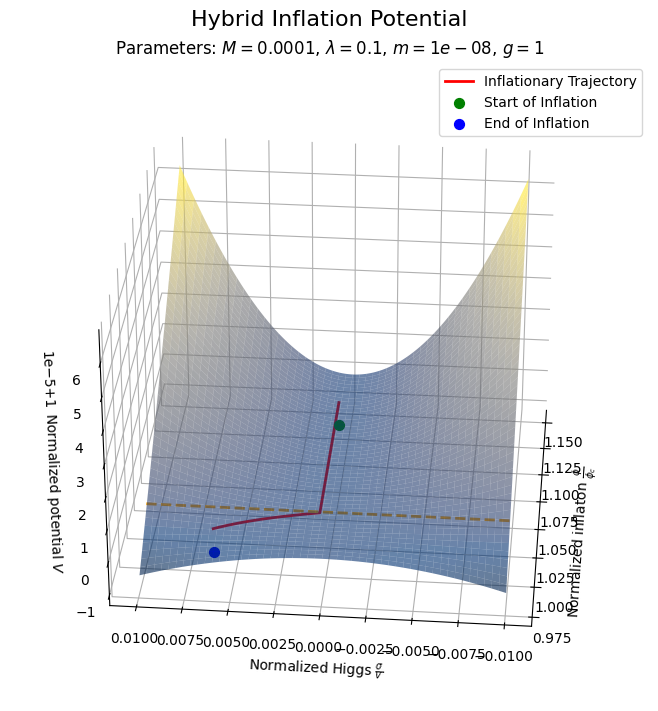

In [264]:
# critical phi
phi_c = M / g

# Use normalized plotting variables so transition and wells are easy to see
phi_n = np.linspace(0.98, 1.15, 5000)
phi = phi_n * phi_c
sigma_n = np.linspace(-1, 1, 5000)*10**(-2)
sigma = sigma_n * (M/np.sqrt(lamb))

# Create meshgrids
Phi_n, Sigma_n = np.meshgrid(phi_n, sigma_n)
Phi, Sigma = np.meshgrid(phi, sigma)

# Compute and normalize potential for visualization
V_values = V(Sigma, Phi, M, lamb, m, g)
V_values = V_values / V(0,0, M, lamb, m, g)  # normalized so numbers are O(1)
for i in range(len(V_values)):
    for j in range(len(V_values[0])):
        if V_values[i][j] > 6:
            V_values[i][j] = 6
# Plot the surface (normalized axes)
fig = plt.figure(figsize=(10, 7), layout='constrained')
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(Phi_n, Sigma_n, V_values, antialiased=True, 
                       cmap='cividis', edgecolor='none', alpha = 0.6)

# Normalize the trajectory for plotting
phi_traj_n = phi_eof / phi_c
sigma_traj_n = sigma_eof / (M/np.sqrt(lamb))
V_traj_n = V(sigma_eof, phi_eof, M, lamb, m, g) / V(0,0, M, lamb, m, g)
eps = 10**(-1)*(np.max(V_values) - np.min(V_values))  # Small offset to ensure visibility
ax.plot3D(phi_traj_n, sigma_traj_n, V_traj_n+eps, color='red', linewidth=2, label='Inflationary Trajectory')
ax.scatter3D(phi_traj_n[0], sigma_traj_n[0], V_traj_n[0], color='green', s=50, label='Start of Inflation')
ax.scatter3D(phi_traj_n[-1], sigma_traj_n[-1], V_traj_n[-1], color='blue', s=50, label='End of Inflation')
ax.legend()

V_critic_traj = V(sigma, phi_c, M, lamb, m, g) / V(0,0, M, lamb, m, g)
ax.plot3D(1, sigma_n, V_critic_traj+eps, color='orange', linestyle='--', linewidth=2, label='phi_c')

ax.xaxis.pane.set_alpha(0)
ax.yaxis.pane.set_alpha(0)
ax.zaxis.pane.set_alpha(0)
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.set_xlabel(r'Normalized inflaton $\frac{\phi}{\phi_c}$')
ax.set_ylabel(r'Normalized Higgs $\frac{\sigma}{v}$', rotation=90)
ax.set_zlabel(r'Normalized potential $V$')
ax.set_title(rf"Parameters: $M={M:.2g}$, $\lambda={lamb:.2g}$, $m={m:.2g}$, $g={g:.2g}$", fontsize=12)
fig.suptitle('Hybrid Inflation Potential', fontsize=16)
ax.view_init(elev=30, azim=185)
plt.show()

Without respecting the conditions

In [6]:
# Solving for the end of inflation with given parameters
M = 10**(6)*10**(-10)
lamb = 0.0000001
m = 10**(2)*10**(-10)
g = 1
print(rf"{M**2} >> {(lamb*(m**2))/(g**2)}")
print(rf"{M**3} << {lamb*m}")
print(rf"{M**3} << {np.sqrt(lamb)*g*m}")
params = [M, lamb, m, g]

1e-08 >> 1.0000000000000001e-23
1.0000000000000002e-12 << 9.999999999999999e-16
1.0000000000000002e-12 << 3.1622776601683794e-12


In [8]:
phi_eof, sigma_eof, phi_dot, sigma_dot, t, H = eof(params, phi_in_n = 1.1, tdiffbig=100000, tdiffsmall=200, tdiffdetail = 0.01)

9.874567999999119e-18 0.00010999594320159076 0.0001 1e-07 9.128709291752971e-06
9.873839665579769e-18 0.00010999188655279617 0.0001 1e-07 9.128709291752971e-06
9.87311138488135e-18 0.00010998783005361073 0.0001 1e-07 9.128709291752971e-06
9.872383157899908e-18 0.00010998377370402893 0.0001 1e-07 9.128709291752971e-06
9.871654984631472e-18 0.00010997971750404523 0.0001 1e-07 9.128709291752971e-06
9.870926865072089e-18 0.00010997566145365413 0.0001 1e-07 9.128709291752971e-06
9.87019879921779e-18 0.00010997160555285011 0.0001 1e-07 9.128709291752971e-06
9.869470787064617e-18 0.00010996754980162766 0.0001 1e-07 9.128709291752971e-06
9.86874282860861e-18 0.00010996349419998125 0.0001 1e-07 9.128709291752971e-06
9.868014923845814e-18 0.00010995943874790537 0.0001 1e-07 9.128709291752971e-06
9.867287072772252e-18 0.0001099553834453945 0.0001 1e-07 9.128709291752971e-06
9.866559275383977e-18 0.00010995132829244313 0.0001 1e-07 9.128709291752971e-06
9.865831531677028e-18 0.00010994727328904575

In [11]:
phi_c = M / g
mask = phi_eof < phi_c
t_efolds = t[mask]
H_efolds = H[mask]
print(t_efolds)
e_folds = integrate.simpson(H_efolds, t_efolds)
print(f"Number of e-folds: {e_folds}")

[2.58500000e+08 2.58500200e+08 2.58500400e+08 ... 2.61496973e+08
 2.61503027e+08 2.61503027e+08]
Number of e-folds: 27.428193393682005


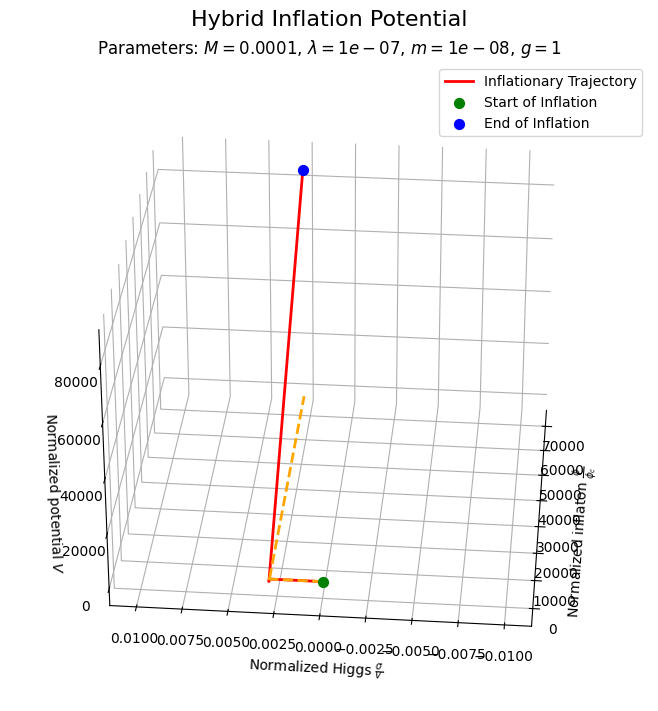

In [234]:
# critical phi
phi_c = M / g

# Use normalized plotting variables so transition and wells are easy to see
phi_n = np.linspace(0.98, 1.15, 5000)
phi = phi_n * phi_c
sigma_n = np.linspace(-1, 1, 5000)*10**(-2)
sigma = sigma_n * (M/np.sqrt(lamb))

# Create meshgrids
Phi_n, Sigma_n = np.meshgrid(phi_n, sigma_n)
Phi, Sigma = np.meshgrid(phi, sigma)

# Compute and normalize potential for visualization
V_values = V(Sigma, Phi, M, lamb, m, g)
V_values = V_values / V(0,0, M, lamb, m, g)  # normalized so numbers are O(1)
for i in range(len(V_values)):
    for j in range(len(V_values[0])):
        if V_values[i][j] > 6:
            V_values[i][j] = 6
# Plot the surface (normalized axes)
fig = plt.figure(figsize=(10, 7), layout='constrained')
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(Phi_n, Sigma_n, V_values, antialiased=True, 
                       cmap='cividis', edgecolor='none', alpha=0.5)

# Normalize the trajectory for plotting
phi_traj_n = phi_eof / phi_c
sigma_traj_n = sigma_eof / (M/np.sqrt(lamb))
V_traj_n = V(sigma_eof, phi_eof, M, lamb, m, g) / V(0,0, M, lamb, m, g)
eps = 1e-3 * (np.max(V_values) - np.min(V_values))  # Small offset to ensure visibility
ax.plot(phi_traj_n, sigma_traj_n, V_traj_n+eps, color='red', linewidth=2, label='Inflationary Trajectory')
ax.scatter3D(phi_traj_n[0], sigma_traj_n[0], V_traj_n[0], color='green', s=50, label='Start of Inflation')
ax.scatter3D(phi_traj_n[-1], sigma_traj_n[-1], V_traj_n[-1], color='blue', s=50, label='End of Inflation')
ax.legend()

V_critic_traj = V(sigma_eof, phi_c, M, lamb, m, g) / V(0,0, M, lamb, m, g)
ax.plot(phi_traj_n, sigma_traj_n, V_critic_traj+eps, color='orange', linestyle='--', linewidth=2, label='phi_c')



ax.xaxis.pane.set_alpha(0)
ax.yaxis.pane.set_alpha(0)
ax.zaxis.pane.set_alpha(0)
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.set_xlabel(r'Normalized inflaton $\frac{\phi}{\phi_c}$')
ax.set_ylabel(r'Normalized Higgs $\frac{\sigma}{v}$', rotation=90)
ax.set_zlabel(r'Normalized potential $V$')
ax.set_title(rf"Parameters: $M={M:.2g}$, $\lambda={lamb:.2g}$, $m={m:.2g}$, $g={g:.2g}$", fontsize=12)
fig.suptitle('Hybrid Inflation Potential', fontsize=16)
ax.view_init(elev=30, azim=185)
plt.show()